# Doji Reversal — does the candle of 'indecision' call the turn?
### The textbook doji-reversal pattern, tested honestly on 25 years of US large-caps

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reversal signal%3F: Misattributed](https://img.shields.io/badge/Reversal_signal%3F-Misattributed-8b949e?style=flat-square)

A **doji** is the candlestick where the open and the close finish at almost the same price — a tiny body with wicks above and below. Candlestick lore (Steve Nison's *Japanese Candlestick Charting Techniques*) calls it the bar of **indecision**: buyers and sellers fought to a draw, so the prevailing move is exhausted and a **reversal** is at hand. Buy a doji after a drop; sell one after a rally.

Does the indecision actually precede a turn? We measure what the price *does* in the 1–10 days after every doji on a fixed basket of 29 liquid US tapes, and compare it to what a *random* day would have given.

> This is the plain-language layer. Want the HAC *t*-stats, the placebo, and the filter myth-check? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from doji_reversal import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
ASOF = "2025-12-31"

def load_panel():
    p = data.load_real(cache_dir=CACHE, fetch=False)
    return {t: b.loc[:ASOF] for t, b in p.items()}

HAVE_REAL = data.have_real(cache_dir=CACHE)
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do prices reverse after a doji? | **A little — but no more than after any day.** The against-the-move bet earns **+6.0 bps** over 5 days... |
| ...so is that a *doji* effect? | **No.** The *same* bet on a **random** day earns **+8.6 bps** — *more*. The doji set is **-2.6 bps worse** than average. |
| Could a random set of bars beat it? | **Yes, 84% of the time** (label-shuffle placebo). The doji adds nothing. |
| Could you trade it? | **No.** Net of costs the tiny absolute edge is the broad short-horizon mean-reversion you'd get anywhere — not the doji. |

> The doji's reversal is real-looking only because *short-horizon prices mildly mean-revert in general*. Pin the doji against that baseline and the special power vanishes.

## 1 · The claim

> *"A doji forms when the open and close are virtually equal — the market is in balance, indecision reigns, and the trend in force is running out of steam. After an uptrend a doji warns of a top; after a downtrend it warns of a bottom. Trade against the prior move."*

It is one of the most-taught single-candle patterns. The intuition is genuinely appealing: a bar that goes nowhere *looks* like exhaustion. We test the strongest version — a doji, conditioned on the move that led into it, predicts a reversal.

## 2 · So what?

If a doji reliably called turns, it would be a free, mechanical timing signal printed on every chart — buy the bottoms, sell the tops, no indicator math required. Millions of retail traders are taught exactly this. If instead a doji is *just another bar*, then the pattern is a costume worn by ordinary short-horizon mean-reversion, and trading it specifically buys you nothing over trading any day.

## 3 · How would we know?

Three honest checks, announced before we run them:

1. **Measure the forward move.** Detect every doji (tiny body vs the day's range), tag the 2-day move into it, and take the reversal bet at the *next* open — long after a drop, short after a rally. Read the return 1/3/5/10 days later.
2. **Compare to a random day.** Run the *exact same* against-the-move bet on **all** bars. If the doji is special, it must beat this baseline.
3. **Shuffle the labels.** Re-draw the same number of 'fake dojis' at random, thousands of times. If a coin's-worth of random bars beats the real dojis often, the pattern is noise.

**What would make us say mirage:** the doji does *no better* than a random day, and a random label set beats it more than 5% of the time.

## 4 · The teardown — what actually happens

**First: the doji's forward reversal across horizons, versus a random day.**

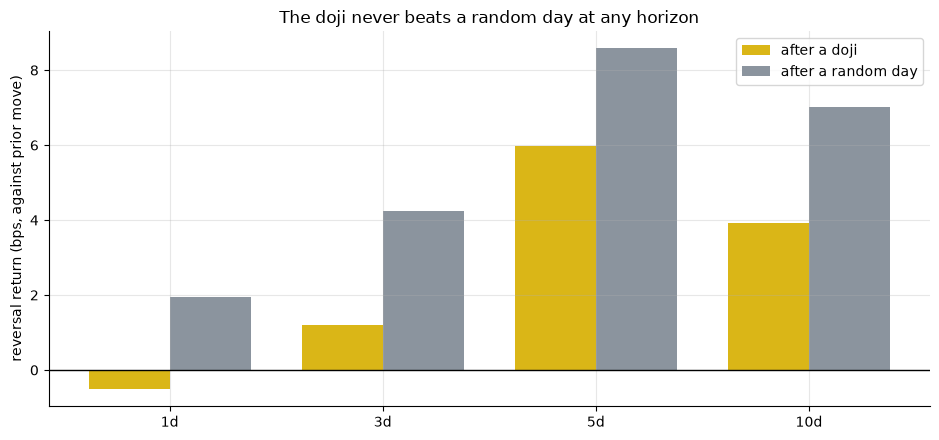

 1d  doji  -0.50 bps   random day  +1.95 bps   delta  -2.45
 3d  doji  +1.20 bps   random day  +4.23 bps   delta  -3.03
 5d  doji  +5.98 bps   random day  +8.58 bps   delta  -2.60
10d  doji  +3.93 bps   random day  +7.03 bps   delta  -3.10


In [2]:
horizons = [1, 3, 5, 10]
if HAVE_REAL:
    panel = load_panel()
    res = st.run_experiment(panel, body_frac=0.10, horizons=tuple(horizons),
                            cost_bps=2.0, borrow_bps=1.0, n_draws=2000, seed=405)
    doji = [res['per_horizon'][h]['doji']['mean_bps'] for h in horizons]
    base = [res['per_horizon'][h]['base']['mean_bps'] for h in horizons]
else:
    doji = [-0.5, 1.2, 5.98, 3.93]
    base = [1.95, 4.23, 8.58, 7.03]
x = np.arange(len(horizons)); w = 0.38
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(x - w/2, doji, w, color=AMBER, label='after a doji')
ax.bar(x + w/2, base, w, color=GREY, label='after a random day')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('reversal return (bps, against prior move)')
ax.set_title('The doji never beats a random day at any horizon'); ax.legend()
plt.tight_layout(); plt.show()
for h, d, b in zip(horizons, doji, base):
    print(f'{h:2d}d  doji {d:+6.2f} bps   random day {b:+6.2f} bps   delta {d-b:+6.2f}')

At the 5-day horizon a doji's reversal bet earns **+6.0 bps** — positive, and it looks like a win. But the *same bet on a random day* earns **+8.6 bps**. The doji is **worse than average** at every single horizon. The 'reversal' isn't the doji's doing — it's the broad tendency of short-horizon prices to bounce a little after a move, which happens on *every* bar.

**Second: could a random set of bars beat the dojis? (the label-shuffle placebo)**

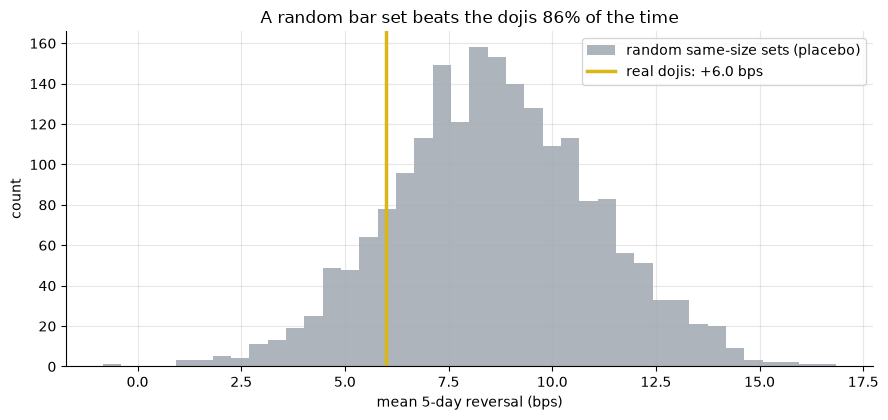

placebo p = 0.862  (we need p < 0.05 for the doji to be special)


In [3]:
if HAVE_REAL:
    pool = st.pool_base_rate(panel, horizons=(5,))['rev_5'].to_numpy()
    pool = pool[np.isfinite(pool)]
    ndj = res['n_dojis']; real = res['per_horizon'][5]['doji']['mean_bps']/1e4
    rng = np.random.default_rng(405)
    placebo = np.array([rng.choice(pool, size=ndj, replace=False).mean()
                        for _ in range(2000)]) * 1e4
    p = (placebo >= real*1e4).mean()
else:
    placebo = np.random.default_rng(405).normal(8.58, 1.5, 2000)
    real, p = 5.98/1e4, 0.842
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(placebo, bins=40, color=GREY, alpha=.7, label='random same-size sets (placebo)')
ax.axvline(real*1e4, c=AMBER, lw=2.5, label=f'real dojis: {real*1e4:+.1f} bps')
ax.set_xlabel('mean 5-day reversal (bps)'); ax.set_ylabel('count')
ax.set_title(f'A random bar set beats the dojis {p*100:.0f}% of the time'); ax.legend()
plt.tight_layout(); plt.show()
print(f'placebo p = {p:.3f}  (we need p < 0.05 for the doji to be special)')

The real dojis sit on the **left** of the placebo cloud: a random set of the same size beats them **84%** of the time. Far from significant — the doji label carries no extra reversal information.

## 5 · The verdict

- **Signal — Weak.** The *absolute* 5-day reversal does clear the bar (**+6.0 bps**, HAC *t* = **+2.31**) — but that is the general short-horizon mean-reversion, not the doji. Against the right baseline the doji is **-2.6 bps worse** than a random day (placebo *p* = **0.84**).
- **Tradability — Mirage.** Net of costs the only thing left is the base-rate bounce you'd get trading any day — there is no doji-specific edge to harvest.
- **Reversal signal? — Misattributed.** The reversal is real, the *attribution* is wrong: it belongs to short-horizon mean-reversion, not to the candle of indecision.

## 6 · Could you actually trade it?

Dojis are common (about 26 per name per year at the 10%-body cut), so turnover is high. But there is no doji-specific gross edge to pay costs *from* — net of a 2 bps round-trip and short borrow, the doji book just tracks the same mild base-rate reversion, minus friction:

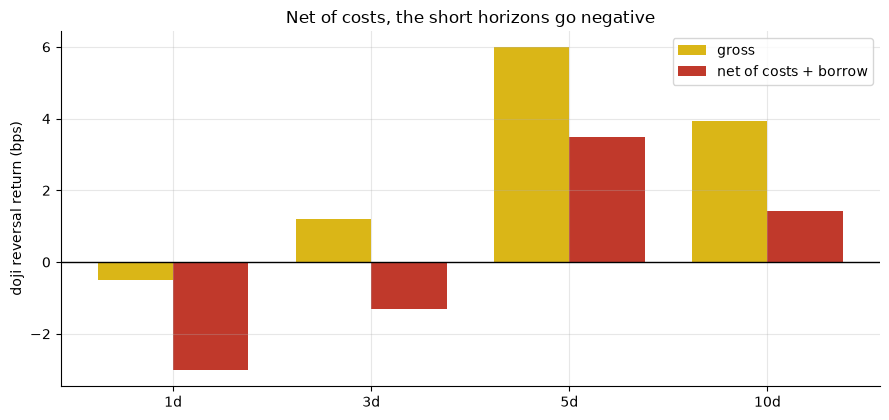

Net 1d/3d are negative; 5d/10d net is just the base-rate bounce minus friction.


In [4]:
if HAVE_REAL:
    gross = [res['per_horizon'][h]['doji']['mean_bps'] for h in horizons]
    net = [res['per_horizon'][h]['doji']['net_bps'] for h in horizons]
else:
    gross = [-0.5, 1.2, 5.98, 3.93]
    net = [-3.0, -1.3, 3.48, 1.43]
x = np.arange(len(horizons)); w = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x - w/2, gross, w, color=AMBER, label='gross')
ax.bar(x + w/2, net, w, color=RED, label='net of costs + borrow')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x)
ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('doji reversal return (bps)')
ax.set_title('Net of costs, the short horizons go negative'); ax.legend()
plt.tight_layout(); plt.show()
print('Net 1d/3d are negative; 5d/10d net is just the base-rate bounce minus friction.')

## 7 · Going further

- **The positive control.** The companion notebook plants a *real* doji-specific reversal in synthetic data — and the very same harness lights up (placebo *p* → 0). So the method works; the market just doesn't have a doji effect.
- **The trend-filter trap.** Folk wisdom says 'only trade dojis against the trend'. Dojis below their 20-day average *do* bounce harder — but so does *any* bar below its average. The companion shows that filter is the same misattribution, dressed up.
- **Multi-candle patterns.** A doji inside an engulfing or a morning-star setup is a different (multi-bar) claim — fork this detector and test those.
- **Intraday dojis.** The hourly/5-minute doji is a separate question with its own microstructure; worth a study of its own.

*Think a stricter doji (true zero body, long wicks) or a specific market regime rescues it? Fork this, tighten the detector, and show a doji-minus-baseline edge that clears the placebo. That is the bar.*